In [1]:
import mediapy as media
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Polygon
import os
import cv2
import json
from openpyxl import load_workbook

In [3]:
raw_data_path = "Fixed_Camera_Clips-AnimalKingdom"
save_data_path = "Drag_DataSet"
os.makedirs(save_data_path, exist_ok=True)

In [8]:
def extract_frame(video_path: Path, second: int):
    with media.VideoReader(video_path) as reader:
        # Calculate the frame index corresponding to the given second
        frame_index = int(second * reader.fps)
        # Iterate through frames until the desired frame is reached
        for i, frame in enumerate(reader):
            if i == frame_index:
                return frame
        raise ValueError(f"Video is shorter than {second} seconds.")

In [2]:
def blend_frames(frame1, frame2, alpha=0.5):
    # Ensure both frames have the same shape
    assert frame1.shape == frame2.shape, "Frames must be the same shape to blend"
    # Blend the frames: (1 - alpha) * frame1 + alpha * frame2
    blended = (1 - alpha) * frame1 + alpha * frame2
    return blended.astype(np.uint8)

In [27]:
# open excel file and search for video_name
def get_actions(video_name):
    data = {}
    wb = load_workbook("AR_metadata.xlsx")
    # search in sheet AR
    sheet = wb["AR"]
    for row in sheet.iter_rows(values_only=True):
        if row[1] == video_name:
            labels = row[3].split(",")
            data["animal-name"] = row[4].split(",")[0].replace("[","").replace("'","").replace("(","")

            action_sheet = wb["Action"]
            for label in labels:
                for action_row in action_sheet.iter_rows(values_only=True):
                    if action_row[0] == int(label):
                        data[f"action-{action_row[2]}"] = action_row[3]
                        break
            return data

## ReRUN from here

In [46]:
for video in os.listdir(raw_data_path):
    video_name = video.split(".")[0]
    if os.path.isdir(Path(save_data_path) / Path(video_name)) or video_name.startswith(
        "REMOVED"
    ):
        continue
    else:
        os.makedirs(Path(save_data_path) / Path(video_name), exist_ok=True)
        current_sample_name = video_name
        break

In [3]:
raw_data_path = "../frames10"  # --- IGNORE ---

In [4]:
video_name = "pexels_landscape_landscape_5708309_001"

In [4]:
video_path = Path(raw_data_path) / f"{video_name}.mp4"
video = media.read_video(video_path)
print(video_name)
media.show_video(video)

AGNEFGHA


This browser does not support the video tag.


## Explore the video
enter the two seconds of first frame and last frame in next cell.
then run the below cells.

In [12]:
first_frame_second = 1
last_frame_second = 3.8

In [ ]:
frame2 = extract_frame(video_path, last_frame_second)

""

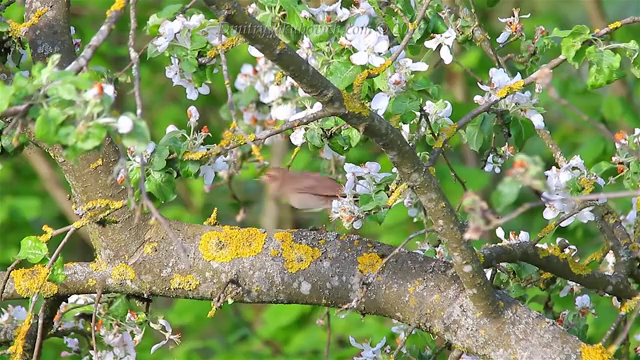

In [14]:
media.show_image(frame2)

In [ ]:
# extract the frames from first_frame_second and last frame as two images
frame1 = extract_frame(video_path, first_frame_second)
media.write_image(
    Path(save_data_path)
    / Path(current_sample_name)
    / Path(f"{current_sample_name}_frame1.jpg"),
    frame1,
)
frame2 = extract_frame(video_path, last_frame_second)
media.write_image(
    Path(save_data_path)
    / Path(current_sample_name)
    / Path(f"{current_sample_name}_frame2.jpg"),
    frame2,
)

## Draw the arrows
when you run the next cell, you have an interactive interface to select the points on the images. play with opacity (alpha) if you can't find start or end point.

after you finished, run further cell to save your data.

In [5]:
from PIL import Image
frame1 = np.array(Image.open(
    Path(raw_data_path)
    / Path(video_name)
    / Path(f"{video_name}_frame1.jpg")
))
frame2 = np.array(Image.open(
    Path(raw_data_path)
    / Path(video_name)
    / Path(f"{video_name}_frame2.jpg")
))
blended_frame = blend_frames(frame1, frame2, alpha=0.5)

15

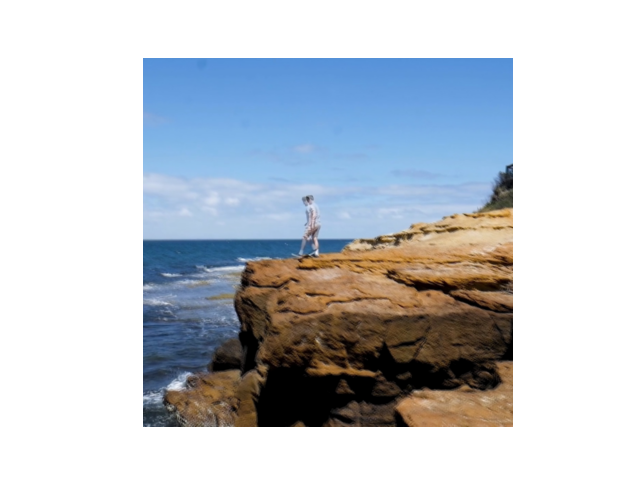

In [11]:
%matplotlib ipympl
user_points = []

blended_frame = blend_frames(frame1, frame2, alpha=0.5)
fig, ax = plt.subplots(1, 1)
ax.imshow(blended_frame)
ax.axis("off")
plt.draw()

def mouse_event(event):
    y, x = event.ydata, event.xdata
    radius = 10
    color = "gray"
    circ = plt.Circle((x, y), radius, facecolor=color, color=color)
    ax.add_patch(circ)
    if len(user_points) % 2 == 1:
        arrow = FancyArrowPatch(user_points[-1], (x, y),
                            arrowstyle='->', color='red', mutation_scale=20, linewidth=2)
        ax.add_patch(arrow)
    user_points.append((x, y))

fig.canvas.mpl_connect('button_press_event', mouse_event)

In [12]:
tracks_file = f"tracks_{video_name}.npy"
assert (
    user_points and len(user_points) % 2 == 0
), "Every source point must have a target point"
user_arr = np.array(user_points)
source_arr, target_arr = user_arr[0::2, :], user_arr[1::2, :]
tracks = np.stack([source_arr, target_arr])[None, ...]
np.save(Path(raw_data_path) / Path(video_name) / Path(tracks_file), tracks)

In [54]:
tracks_file = f"tracks_{current_sample_name}.npy"
assert (
    user_points and len(user_points) % 2 == 0
), "Every source point must have a target point"
user_arr = np.array(user_points)
source_arr, target_arr = user_arr[0::2, :], user_arr[1::2, :]
tracks = np.stack([source_arr, target_arr])[None, ...]
np.save(Path(save_data_path) / Path(current_sample_name) / Path(tracks_file), tracks)

## Draw the mask

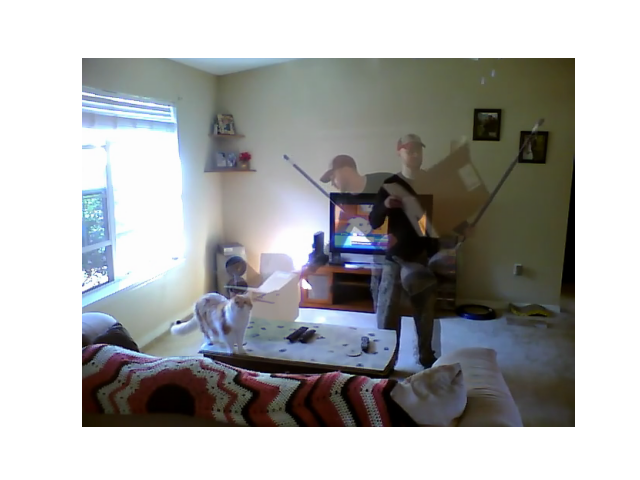

In [25]:
%matplotlib ipympl
mask_points = []

fig, ax = plt.subplots(1, 1)
ax.imshow(blended_frame)
ax.axis("off")
plt.draw()

def mask_event(event):
    if event.inaxes:
        x, y = event.xdata, event.ydata
        mask_points.append((x, y))
        circ = plt.Circle((x, y), radius=5, facecolor='blue', edgecolor='blue')
        ax.add_patch(circ)
        plt.draw()
        
        if len(mask_points) == 4:
            polygon = Polygon(mask_points, closed=True, fill=True, edgecolor='blue', facecolor='blue', alpha=0.3)
            ax.add_patch(polygon)
            plt.draw()
            fig.canvas.mpl_disconnect(cid)

cid = fig.canvas.mpl_connect('button_press_event', mask_event)


In [26]:
mask_file = f"mask_{video_name}.npy"
assert mask_points and len(mask_points) == 4, "draw a polygon with 4 points"

# Create a mask with the same dimensions as the faded_frame
mask = np.zeros_like(blended_frame, dtype=np.uint8)

# Create a polygon mask
polygon = np.array(mask_points, dtype=np.int32)
cv2.fillPoly(mask, [polygon], (255, 255, 255))

# Save the mask as a numpy array
np.save(Path(raw_data_path) / Path(video_name) / Path(mask_file), mask)

In [56]:
mask_file = f"mask_{current_sample_name}.npy"
assert mask_points and len(mask_points) == 4, "draw a polygon with 4 points"

# Create a mask with the same dimensions as the faded_frame
mask = np.zeros_like(blended_frame, dtype=np.uint8)

# Create a polygon mask
polygon = np.array(mask_points, dtype=np.int32)
cv2.fillPoly(mask, [polygon], (255, 255, 255))

# Save the mask as a numpy array
np.save(Path(save_data_path) / Path(current_sample_name) / Path(mask_file), mask)

## Extract the caption
copy and paste only the part of the caption that related to extracted frames.

In [41]:
data = get_actions(video_name)
data

{'animal-name': 'Singing Nightingale',
 'action-Attending': 'Animal locates a stimulus of potential interest, and directs its attention (eyes, ears, face) towards it, and often keeping very still to observe the situation',
 'action-Chirping': None}

In [57]:
caption = "Nightingale closes its mouth."

In [58]:
# write the metadata into json file in the same directory
metadata = {
    "caption": caption,
    "first_frame_second": first_frame_second,
    "last_frame_second": last_frame_second,
}
metadata_file = f"metadata_{current_sample_name}.json"
json.dump(
    metadata,
    open(Path(save_data_path) / Path(current_sample_name) / Path(metadata_file), "w"),
)

## Compress whole sample into a gif

In [8]:
mask_file = f"mask_{video_name}.npy"
mask = np.load(Path(raw_data_path) / Path(video_name) / Path(mask_file))

In [6]:
tracks_file = f"tracks_{video_name}.npy"
tracks = np.load(Path(raw_data_path) / Path(video_name) / Path(tracks_file))

First Frame,Edit Frame,Last Frame

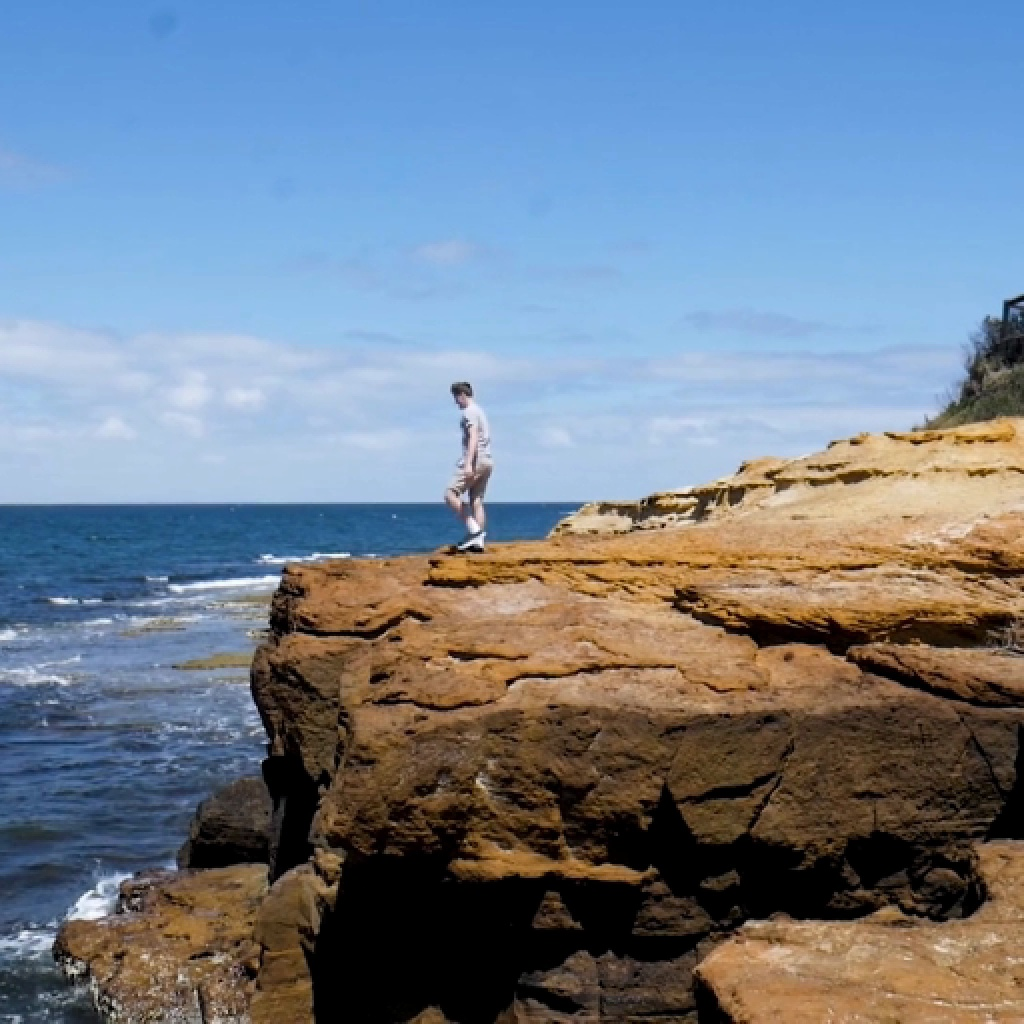
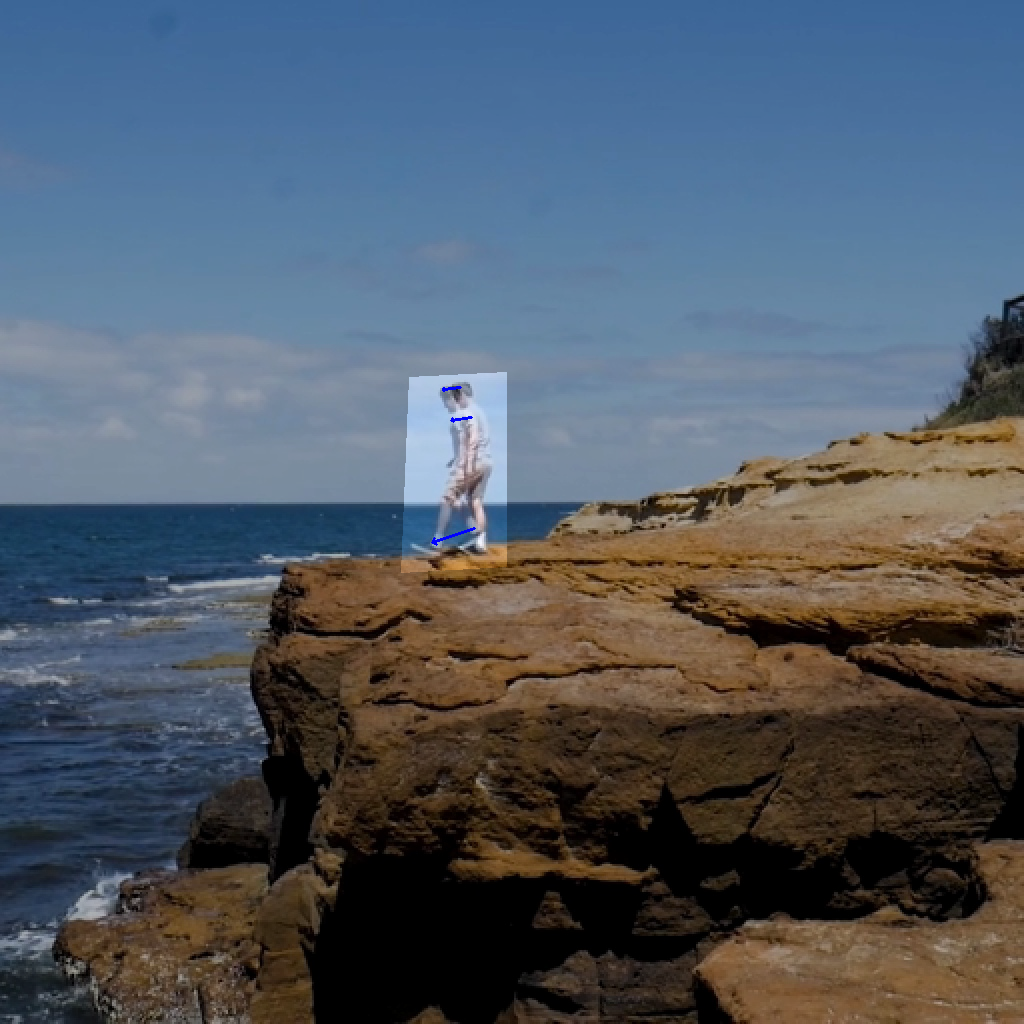
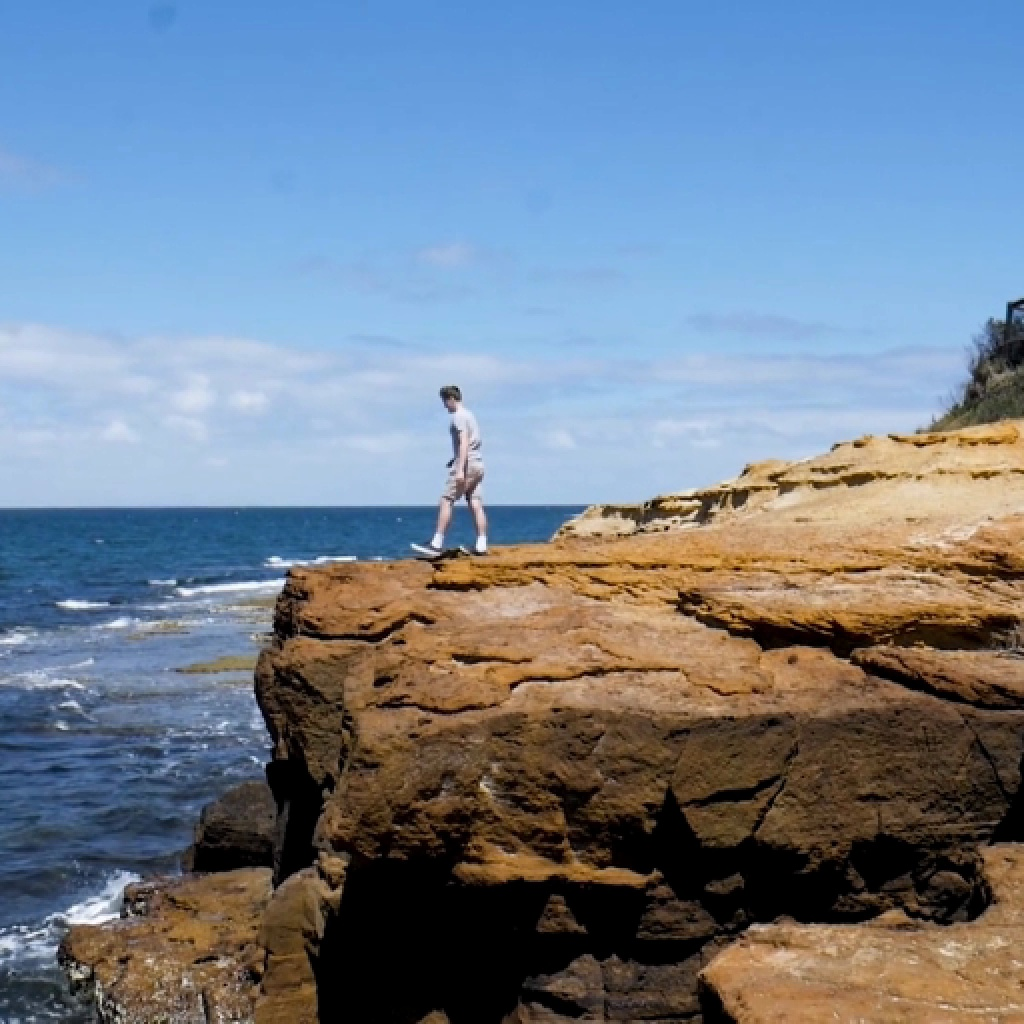

In [13]:
# create a copy of first frame; fade the copy with alpha=0.3 and draw the arrows and the mask on it and save it to edit_frame
# then create a gif from first_frame, edit_frame and last_frame. also write the caption on the top of the gif
edit_frame = (frame1 * 0.7).astype(np.uint8)
edit_frame[mask == 255] = blended_frame[mask == 255]
height, width = edit_frame.shape[:2]
for i in range(tracks.shape[2]):
    pt1 = tuple(map(int, tracks[0, 0, i]))
    pt2 = tuple(map(int, tracks[0, 1, i]))
    if 0 <= pt1[0] < width and 0 <= pt1[1] < height and 0 <= pt2[0] < width and 0 <= pt2[1] < height:
        cv2.arrowedLine(edit_frame, pt1, pt2, (0, 0, 255), 2)
    else:
        print(f"Skipping arrow from {pt1} to {pt2} as it is out of bounds")

media.show_images(
    [frame1, edit_frame, frame2], titles=["First Frame", "Edit Frame", "Last Frame"]
)

In [14]:
frames = [frame1, edit_frame, frame2]
# media.show_video(frames, title=caption, fps=1, codec="gif")
media.write_video(
    Path(raw_data_path) / Path(video_name) / Path(f"{video_name}.gif"),
    frames,
    fps=1,
    codec="gif",
)

In [ ]:
frames = [frame1, edit_frame, frame2]
media.show_video(frames, title=caption, fps=1, codec="gif")
media.write_video(
    Path(save_data_path) / Path(current_sample_name) / Path(f"{current_sample_name}.gif"),
    frames,
    fps=1,
    codec="gif",
)